In [24]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error


In [25]:

# -----------------------------------
# 1. Load dataset
# -----------------------------------
df = pd.read_csv("international-fifa-world-cup-2022-qatar-players-2022-to-2022-stats.csv")


In [26]:

# -----------------------------------
# 2. Select needed columns
# -----------------------------------
df = df[[
    "goals_overall",
    "assists_overall",
    "minutes_played_overall",
    "average_rating_overall"
]]


In [27]:

# -----------------------------------
# 3. Drop missing values
# -----------------------------------
df = df.dropna()


In [28]:

# -----------------------------------
# 4. Define features and target
# -----------------------------------
X = df[["goals_overall", "assists_overall", "minutes_played_overall"]]
y = df["average_rating_overall"]


In [29]:

# -----------------------------------
# 5. Train-test split
# -----------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [30]:

# -----------------------------------
# 6. Linear Regression
# -----------------------------------
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

r2_lr = r2_score(y_test, y_pred_lr)
rmse_lr = mean_squared_error(y_test, y_pred_lr) ** 0.5

print("Linear Regression")
print("R2:", r2_lr)
print("RMSE:", rmse_lr)
print()


Linear Regression
R2: 0.0391067252994004
RMSE: 0.9167149149566716



In [31]:

# -----------------------------------
# 7. Decision Tree
# -----------------------------------
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

r2_dt = r2_score(y_test, y_pred_dt)
rmse_dt = mean_squared_error(y_test, y_pred_dt) ** 0.5

print("Decision Tree")
print("R2:", r2_dt)
print("RMSE:", rmse_dt)
print()


Decision Tree
R2: -1.2244134727954554
RMSE: 1.3947760420228317



In [32]:

# -----------------------------------
# 8. Random Forest
# -----------------------------------
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = mean_squared_error(y_test, y_pred_rf) ** 0.5

print("Random Forest")
print("R2:", r2_rf)
print("RMSE:", rmse_rf)
print()


Random Forest
R2: -0.48628263273979977
RMSE: 1.1401117513122623



In [33]:

# -----------------------------------
# 9. Results Table
# -----------------------------------
results = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree", "Random Forest"],
    "R2": [r2_lr, r2_dt, r2_rf],
    "RMSE": [rmse_lr, rmse_dt, rmse_rf]
})

print("Model Comparison Table")
print(results)


Model Comparison Table
               Model        R2      RMSE
0  Linear Regression  0.039107  0.916715
1      Decision Tree -1.224413  1.394776
2      Random Forest -0.486283  1.140112


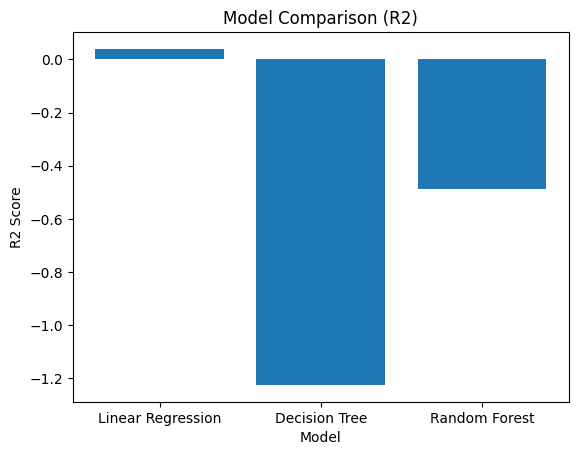

In [34]:

# -----------------------------------
# 10. Bar Chart (R2)
# -----------------------------------
plt.figure()
plt.bar(results["Model"], results["R2"])
plt.title("Model Comparison (R2)")
plt.xlabel("Model")
plt.ylabel("R2 Score")
plt.show()


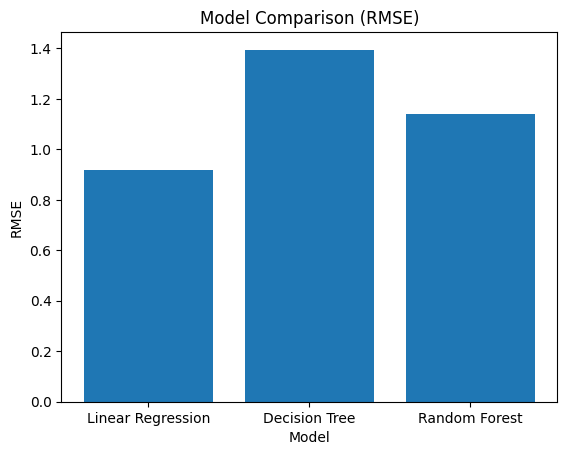

In [35]:

# -----------------------------------
# 11. Bar Chart (RMSE)
# -----------------------------------
plt.figure()
plt.bar(results["Model"], results["RMSE"])
plt.title("Model Comparison (RMSE)")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.show()


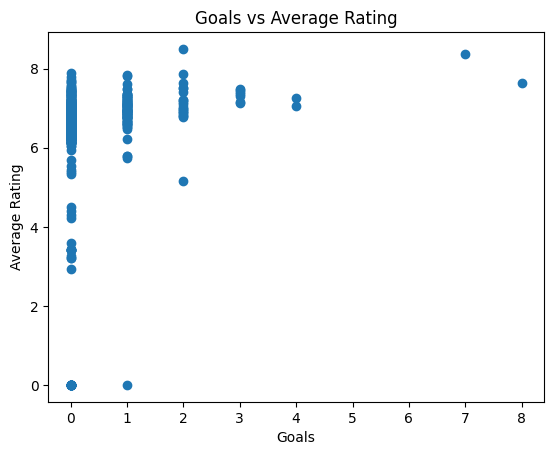

In [36]:

# -----------------------------------
# 12. Scatter Plots
# -----------------------------------

# Goals vs Rating
plt.figure()
plt.scatter(df["goals_overall"], df["average_rating_overall"])
plt.title("Goals vs Average Rating")
plt.xlabel("Goals")
plt.ylabel("Average Rating")
plt.show()


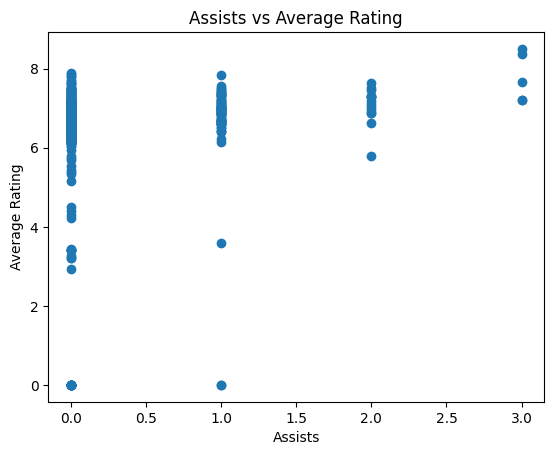

In [37]:

# Assists vs Rating
plt.figure()
plt.scatter(df["assists_overall"], df["average_rating_overall"])
plt.title("Assists vs Average Rating")
plt.xlabel("Assists")
plt.ylabel("Average Rating")
plt.show()


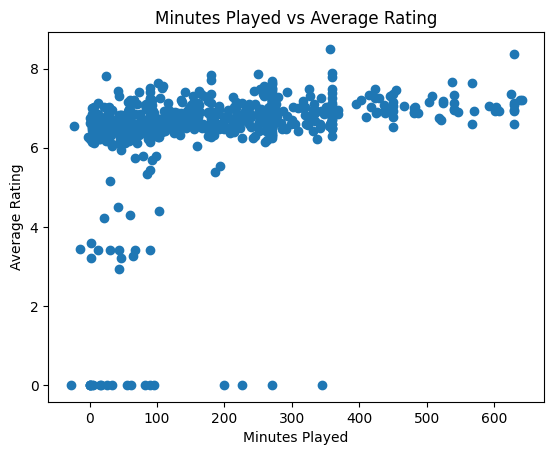

In [38]:

# Minutes vs Rating
plt.figure()
plt.scatter(df["minutes_played_overall"], df["average_rating_overall"])
plt.title("Minutes Played vs Average Rating")
plt.xlabel("Minutes Played")
plt.ylabel("Average Rating")
plt.show()